# Regression in Scikit-learn

In [2]:
# import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
# other 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [3]:
# import dataset
df=sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
# sinple linear regression
x=df[['age']]
y=df['fare']

# Dimensionality:
**Single Brackets** df["fare"]: Returns a Series (a single 1D column).

Double Brackets df[["fare"]]: Returns a DataFrame with one column.

Double Brackets df[["age", "fare"]]: Returns a DataFrame with multiple columns.
# ML Requirements:
 Many machine learning models (like scikit-learn's LinearRegression) require the input features (X) to be a 2D 
 
 structure (DataFrame), while the target (y) can be a 1D structure (Series). Using df[["age", "fare"]] ensures 
 
 the output has the 2D shape these algorithms expect. 

 In pandas, the difference between using single [] or double [[]] square brackets defines the shape and data structure of your output.  
 
 Single Brackets: df['fare'] Result: A pandas Series.Structure:
 
  1-dimensional (just one column of data).Common Use: This is typically used for the Target variable (y) in machine learning models (like "survival" or "fare" if you are predicting it) because the model expects a 1D vector.
  
   2. Double Brackets: df[['age']] Result: A pandas DataFrame.
  ## Structure:
   2-dimensional (a table with rows and columns, even if there is only one column).
  
  ## Common Use:
   This is used for Independent variables (Features, (X). Machine learning models (like those in scikit-learn) often require the input features to be 2D structures, even if you are only using one feature like "age".

In [5]:
x

,age
0,22.0
1,38.0
2,26.0
3,35.0
4,35.0
...,...
886,27.0
887,19.0
888,NaN
889,26.0


In [6]:
y

0       7.2500
1      71.2833
2       7.9250
3      53.1000
4       8.0500
        ...   
886    13.0000
887    30.0000
888    23.4500
889    30.0000
890     7.7500
Name: fare, Length: 891, dtype: float64

In [7]:
x.isnull().sum()/len(x)*100      # missing value percent in age

age    19.86532
dtype: float64

In [8]:
y.isnull().sum()/len(y)*100      # missing value percent in fare

np.float64(0.0)

In [9]:
x['age']=x.age.fillna(value=x['age'].mean())

C:\Users\Hair\AppData\Local\Temp\ipykernel_2104\1876084908.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x['age']=x.age.fillna(value=x['age'].mean())


In [10]:
x.isnull().sum()/len(x)*100      # now missing value percent in age after replacing by mean value of age

age    0.0
dtype: float64

In [11]:
x

,age
0,22.000000
1,38.000000
2,26.000000
3,35.000000
4,35.000000
...,...
886,27.000000
887,19.000000
888,29.699118
889,26.000000


In [12]:
x.isnull().sum()

age    0
dtype: int64

In [13]:
x.shape

(891, 1)

In [14]:
y.shape

(891,)

In [15]:
print(df.columns.tolist())      # To see all available columns

['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


In [16]:
df.columns = df.columns.str.strip()
df_linear = df[["age", "fare"]]

In [17]:
df_linear = df[["age", "fare"]]

In [18]:
df_linear

,age,fare
0,22.0,7.2500
1,38.0,71.2833
2,26.0,7.9250
3,35.0,53.1000
4,35.0,8.0500
...,...,...
886,27.0,13.0000
887,19.0,30.0000
888,NaN,23.4500
889,26.0,30.0000


In [41]:
# simple linear Regression
x=df[['age']]
y=df['fare']

In [20]:
x

,age
0,22.0
1,38.0
2,26.0
3,35.0
4,35.0
...,...
886,27.0
887,19.0
888,NaN
889,26.0


In [21]:
df_linear.age.fillna(value=df_linear['age'].mean(),inplace=True)

C:\Users\Hair\AppData\Local\Temp\ipykernel_2104\1377016597.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_linear.age.fillna(value=df_linear['age'].mean(),inplace=True)
C:\Users\Hair\AppData\Local\Temp\ipykernel_2104\1377016597.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_linear.age.fillna(value=df_linear['age'].mean(),inplace

In [22]:
df_linear.isnull().sum()

age     0
fare    0
dtype: int64

In [23]:
df_linear

,age,fare
0,22.000000,7.2500
1,38.000000,71.2833
2,26.000000,7.9250
3,35.000000,53.1000
4,35.000000,8.0500
...,...,...
886,27.000000,13.0000
887,19.000000,30.0000
888,29.699118,23.4500
889,26.000000,30.0000


In [24]:
x.shape

(891, 1)

<Axes: xlabel='age'>

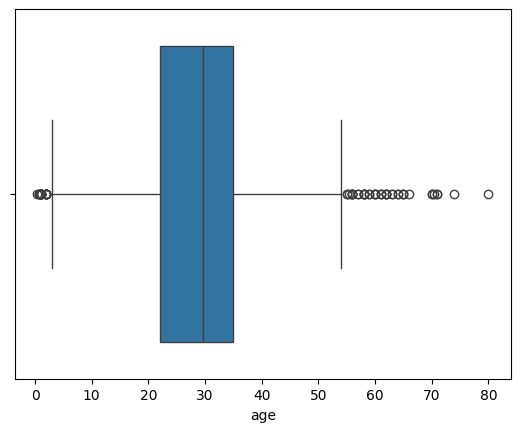

In [25]:
sns.boxplot(data=df_linear,x='age')

<Axes: ylabel='age'>

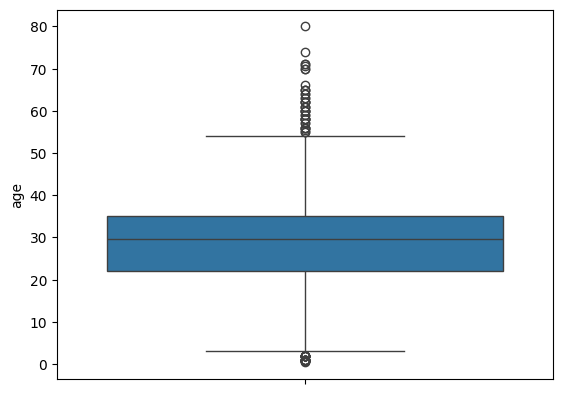

In [26]:
sns.boxplot(data=df_linear,y='age')

In [27]:
df=df[(df['age']>5)&(df['age']<55)]

In [28]:
df_linear=df_linear[(df_linear['age']>8)&(df_linear['age']<50)]        # To remove outliers

<Axes: ylabel='age'>

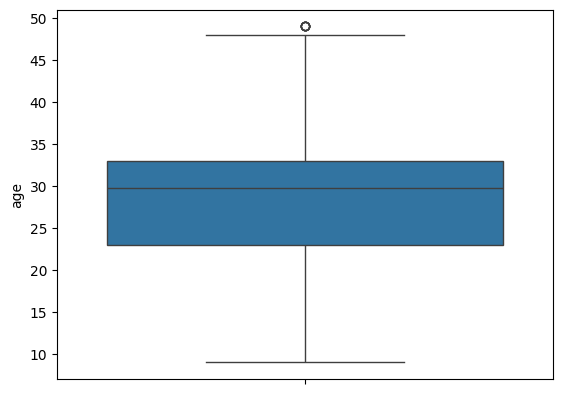

In [29]:
sns.boxplot(data=df_linear,y='age')

<Axes: ylabel='fare'>

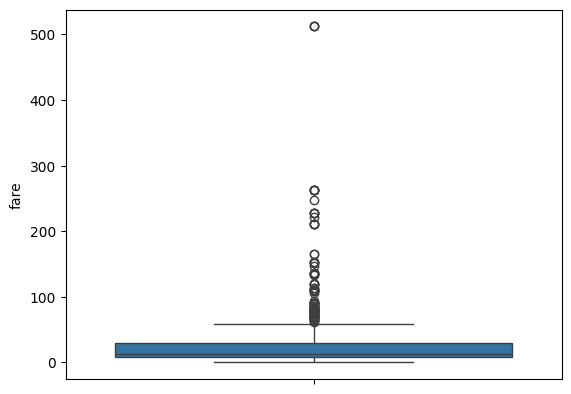

In [30]:
sns.boxplot(data=df_linear,y='fare')

In [31]:
df_linear['fare'].min()

np.float64(0.0)

In [32]:
df_linear=df_linear[(df_linear['fare']>8)&(df_linear['fare']<50)]

<Axes: ylabel='fare'>

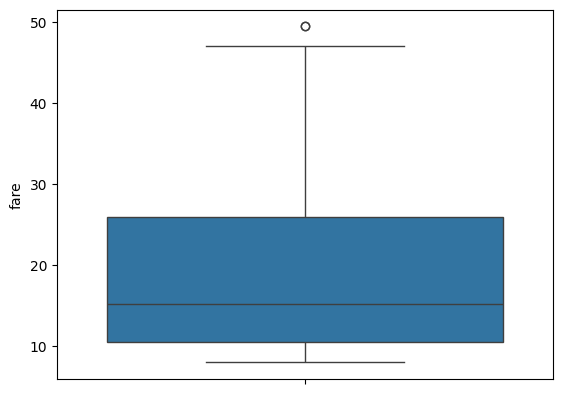

In [33]:
sns.boxplot(data=df_linear,y='fare')

<Axes: ylabel='fare'>

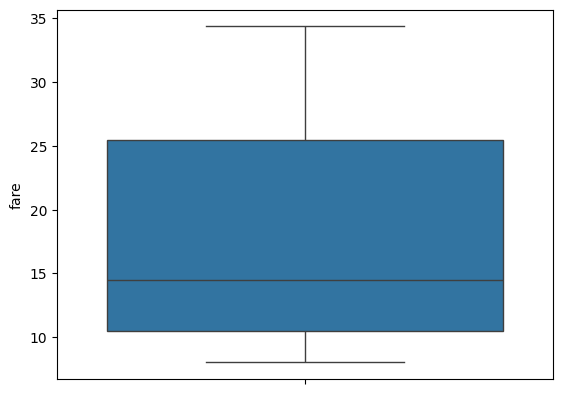

In [34]:
df_linear=df_linear[(df_linear['fare']>8)&(df_linear['fare']<35)]
sns.boxplot(data=df_linear,y='fare')

In [38]:
x=df_linear['age']
y=df_linear['fare']

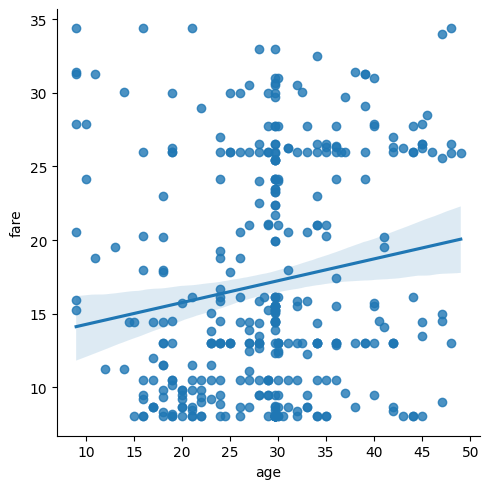

In [36]:
# plot 
sns.lmplot(data=df_linear,x='age',y='fare')

In [42]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
model=LinearRegression()
# train the model
model.fit(x,y)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [45]:
model.predict([[25]])

c:\Users\Hair\AppData\Local\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([32.02415769])

In [46]:
model.predict([[45]])

c:\Users\Hair\AppData\Local\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([42.05460966])

In [47]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
model=LinearRegression()
# train the model
model.fit(x,y)
# prediction
model.predict([[80]])

c:\Users\Hair\AppData\Local\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([59.60790061])

# model evaluation with metrics
For Regression Models (Predicting Continuous Values) 

Mean Absolute Error (MAE): Average of absolute differences between actual and predicted values.

Mean Squared Error (MSE): Average of squared errors, penalizes large errors more.

Root Mean Squared Error (RMSE): Square root of MSE, 

in the same units as the target.R-squared R^{2} Proportion of variance in the dependent variable predictable from the independent variables. 

In [ ]:
# Model evaluation with metrics
# R_squared
# mean squared KeyError
# MAE (mean absolute error)
# RMSE (root mean square error)
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.8)
# model
model=LinearRegression()
# train
model.fit(x_train,y_train)
# prediction
model.predict(x_test)

array([22.30729979, 20.51623253, 28.12826836, 33.0537033 , 30.81486924,
       23.65060023, 17.38186484, 29.4715688 , 31.71040287, 20.96399935,
       31.71040287, 27.68050155, 23.65060023, 25.44166748, 25.44166748,
       24.99390067, 20.51623253, 28.57603517, 34.39700374, 31.71040287,
       20.96399935, 25.44166748, 24.09836704, 21.85953297, 23.65060023,
       22.7550666 , 21.41176616, 34.84477056, 19.17293209, 24.99390067,
       24.99390067, 27.23273473, 21.41176616, 27.23273473, 29.91933561,
       35.74030418, 25.21778407, 34.39700374, 23.65060023, 28.12826836,
       22.7550666 , 32.15816968, 22.7550666 , 31.26263605, 22.30729979,
       36.188071  , 24.09836704, 18.27739847, 26.78496792, 32.15816968,
       29.02380199, 24.99390067, 31.26263605, 33.0537033 , 16.93409803,
       29.4715688 , 27.68050155, 27.23273473, 27.68050155, 36.63583781,
       30.36710243, 29.4715688 , 33.0537033 , 21.85953297, 25.44166748,
       37.08360462, 36.63583781, 21.41176616, 26.33720111, 35.29

In [53]:
# Model evaluation with metrics
# R_squared
# mean squared KeyError
# MAE (mean absolute error)
# RMSE (root mean square error)
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.8)
# model
model=LinearRegression()
# train
model.fit(x_train,y_train)
# prediction
predictions=model.predict(x_test)

In [49]:
x_train.shape

(125, 1)

In [50]:
x_test.shape

(503, 1)

<Axes: xlabel='fare'>

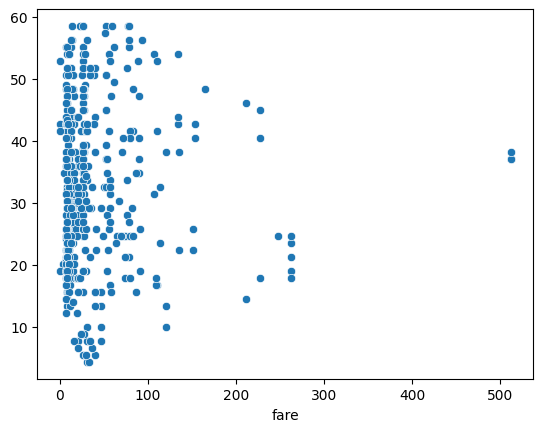

In [55]:
# compare
sns.scatterplot(x=y_test,y=predictions)

In [56]:
model.score(x_test,y_test)

-0.022109926538395497

In [57]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
mean_absolute_error(y_true=y_test,y_pred=predictions)
mean_absolute_error(y_true=y_test,y_pred=predictions)

30.48374276031824

In [64]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np # Import numpy library

# Assuming y_test and predictions are already defined
MAE = mean_absolute_error(y_true=y_test, y_pred=predictions)
MSE = mean_squared_error(y_true=y_test, y_pred=predictions)
R2 = r2_score(y_true=y_test, y_pred=predictions)

# Calculate RMSE by taking the square root of the MSE
RMSE = np.sqrt(MSE) #

# Optional: Print the results
print(f"Mean Absolute Error (MAE): {MAE}")
print(f"Mean Squared Error (MSE): {MSE}")
print(f"Root Mean Squared Error (RMSE): {RMSE}")
print(f"R-squared (R2): {R2}")


Mean Absolute Error (MAE): 30.48374276031824
Mean Squared Error (MSE): 3321.680573462968
Root Mean Squared Error (RMSE): 57.634022707624425
R-squared (R2): -0.022109926538395497


In [68]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np # Import numpy library

# Assuming y_test and predictions are already defined
MAE = mean_absolute_error(y_true=y_test, y_pred=predictions)
MSE = mean_squared_error(y_true=y_test, y_pred=predictions)
R2 = r2_score(y_true=y_test, y_pred=predictions)

# Calculate RMSE by taking the square root of the MSE
RMSE = np.sqrt(MSE) #

# Optional: Print the results
print("MAE:",MAE)
print("MSE:",MSE)
print("RMSE:",RMSE)
print("R2:",R2)

MAE: 30.48374276031824
MSE: 3321.680573462968
RMSE: 57.634022707624425
R2: -0.022109926538395497


In [69]:
import numpy as np
RMSE=np.sqrt(MSE)
RMSE

np.float64(57.634022707624425)